# Linear regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#import mkl

from IPython.display import display, HTML
from matplotlib.animation import FuncAnimation

np.random.seed(1234)
#mkl.set_num_threads(2)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

## Usefull imports

In [3]:
from scipy.stats import multivariate_normal as mvn
from scipy.stats import norm as normal_dist
from numpy.linalg import inv

## Useful utility functions

In [4]:
# Plot 'iso-densities' for MVN
#   ax - axis for plotting,
#   mu, Sigma - MVN parameters,
#   title - plot title.
def plot_mvn(ax, mu, Sigma, title = None, grid_size = 100):
    mu = np.squeeze(mu)
    mu_x, mu_y = mu[0], mu[1]
    s_x, s_y = np.sqrt(Sigma[0, 0]), np.sqrt(Sigma[1, 1])
    
    xmin, xmax = mu_x-3*s_x, mu_x+3*s_x
    ymin, ymax = mu_y-3*s_y, mu_y+3*s_y
    
    X = np.linspace(xmin, xmax, grid_size)
    Y = np.linspace(ymin, ymax, grid_size)
    X, Y = np.meshgrid(X, Y)
    grid = np.vstack([X.flatten(), Y.flatten()]).T
    
    p = mvn(mu, Sigma)
    density = p.pdf(grid).reshape((grid_size, grid_size))

    ax.contour(X, Y, density, zorder=1)
    
    if title is not None:
        ax.set_title(title)
    
    plt.show

In [5]:
# Plot a linear regression fit
#   ax - axis for plotting,
#   w - linear regression parameters
#   data_x, data_y, data_ys - explanatory variables, responses and their uncertainties (data)
#   test_x, test_y, test_ys - explanatory variables, predictions and their uncertainties (test)
#   RSS - residual  sum of squares
#   title - plot title.
def plot_fit(ax, w, data_x, data_y, data_ys, 
             test_x=None, test_y=None, test_ys=None,
             RSS=None, title=None):
    xmin, xmax = np.min(data_x[:, 0]), np.max(data_x[:, 0])
    if test_x is not None:
        test_min, test_max = np.min(test_x[:, 0]), np.max(test_x[:, 0])
        xmin = min(xmin, test_min)
        xmax = max(xmax, test_max)
    
    X = np.array([[xmin, 1], [xmax, 1]])
    y = X @ w
    
    ax.errorbar(data_x[:, 0], data_y[:, 0], data_ys, None, marker="o", ls='', capsize=5)
    if test_x is not None:
        ax.errorbar(test_x[:, 0], test_y, test_ys, None, marker="x", c='g', ls='', capsize=5);
    
    ax.plot(X[:, 0], y, marker='', lw=2.0, color='r');
    
    ax.set_xlabel('x', fontsize='xx-large')
    ax.set_ylabel('y', fontsize='xx-large')
    if RSS is not None:
        ax.text(0.95, 0.01, 'Residual sum of squares: {0:0.1f}'.format(RSS),
                verticalalignment='bottom', horizontalalignment='right',
                transform=ax.transAxes, fontsize=15)
    
    if title is not None:
        ax.set_title(title)

In [6]:
# Plot samples from a Bayesian linear regression
#   ax - axis for plotting,
#   w_samples - samples from the posterior over regression parameters
#   data_x, data_y, data_ys - explanatory variables, responses and their uncertainties (data)
#   title - plot title.
def plot_posterior_samples(ax, w_samples, data_x, data_y, data_ys, title=None):
    ax.errorbar(data_x[:, 0], data_y[:, 0], data_ys, None, marker="o", ls='', capsize=5)
    ax.set_xlabel('x', fontsize='xx-large')
    ax.set_ylabel('y', fontsize='xx-large')

    xmin, xmax = np.min(data_x[:, 0]), np.max(data_x[:, 0])
    X = np.array([[xmin, 1], [xmax, 1]])
    
    for w in w_samples:
        y = X @ w
        ax.plot(X[:, 0], y, marker='', lw=1.0, alpha=0.5, color='r');
    
    if title is not None:
        ax.set_title(title)

## Regression data

In [7]:
# D.W. Hogg et al. Data analysis recipes: Fitting a model to data, https://arxiv.org/abs/1008.4686, 2010
hogg_data = np.array([[201, 592, 61],
                      [244, 401, 25],
                      [47, 583, 38],
                      [287, 402, 15],
                      [203, 495, 21],
                      [58, 173, 15],
                      [210, 479, 27],
                      [202, 504, 14],
                      [198, 510, 30],
                      [158, 416, 16],
                      [165, 393, 14],
                      [201, 442, 25],
                      [157, 317, 52],
                      [131, 311, 16],
                      [166, 400, 34],
                      [160, 337, 31],
                      [186, 423, 42],
                      [125, 334, 26],
                      [218, 533, 16],
                      [146, 344, 22]], dtype=np.float32)

Formally, our model is:

$y = \mathbf{w}^\mathsf{T}\mathbf{x} + b + \epsilon$

However, we can get rid of the bias term $b$ by appending 1s to the explanatory variables and including $b$ in $w$:

$
\mathbf{x} \leftarrow [\mathbf{x}, 1] \\
\mathbf{w} \leftarrow [\mathbf{w}, b]
$

Then our model becomes:

$y = \mathbf{w}^\mathsf{T}\mathbf{x} + \epsilon$

Now, lets pack all explanatory variables to a single matrix $\mathbf{X}$ (each row of $\mathbf{X}$ is a vector of explanatory variables for a single observation). We will then have a following model:

$\mathbf{y} = \mathbf{X}\mathbf{w} + \boldsymbol \epsilon$

Let's prepare our data for this model.

In [8]:
hogg_x, hogg_y, hogg_ys = hogg_data[:, 0], hogg_data[:, 1], hogg_data[:, 2]

hogg_x, hogg_y = hogg_x[:, None], hogg_y[:, None]

ones = np.ones((hogg_x.shape[0], 1))
hogg_x = np.concatenate((hogg_x, ones), axis=1)

In [9]:
print('explanatory variable:')
for x1, x2 in hogg_x[:3, :]:  
       print('{0}\t{1:.1f}'.format(x1, x2))
print('...')

print('\nresponses:')
for y in hogg_y[:3]:  
       print('{0}'.format(y[0]))
print('...')

explanatory variable:
201.0	1.0
244.0	1.0
47.0	1.0
...

responses:
592.0
401.0
583.0
...


---

Now, let's plot this data.

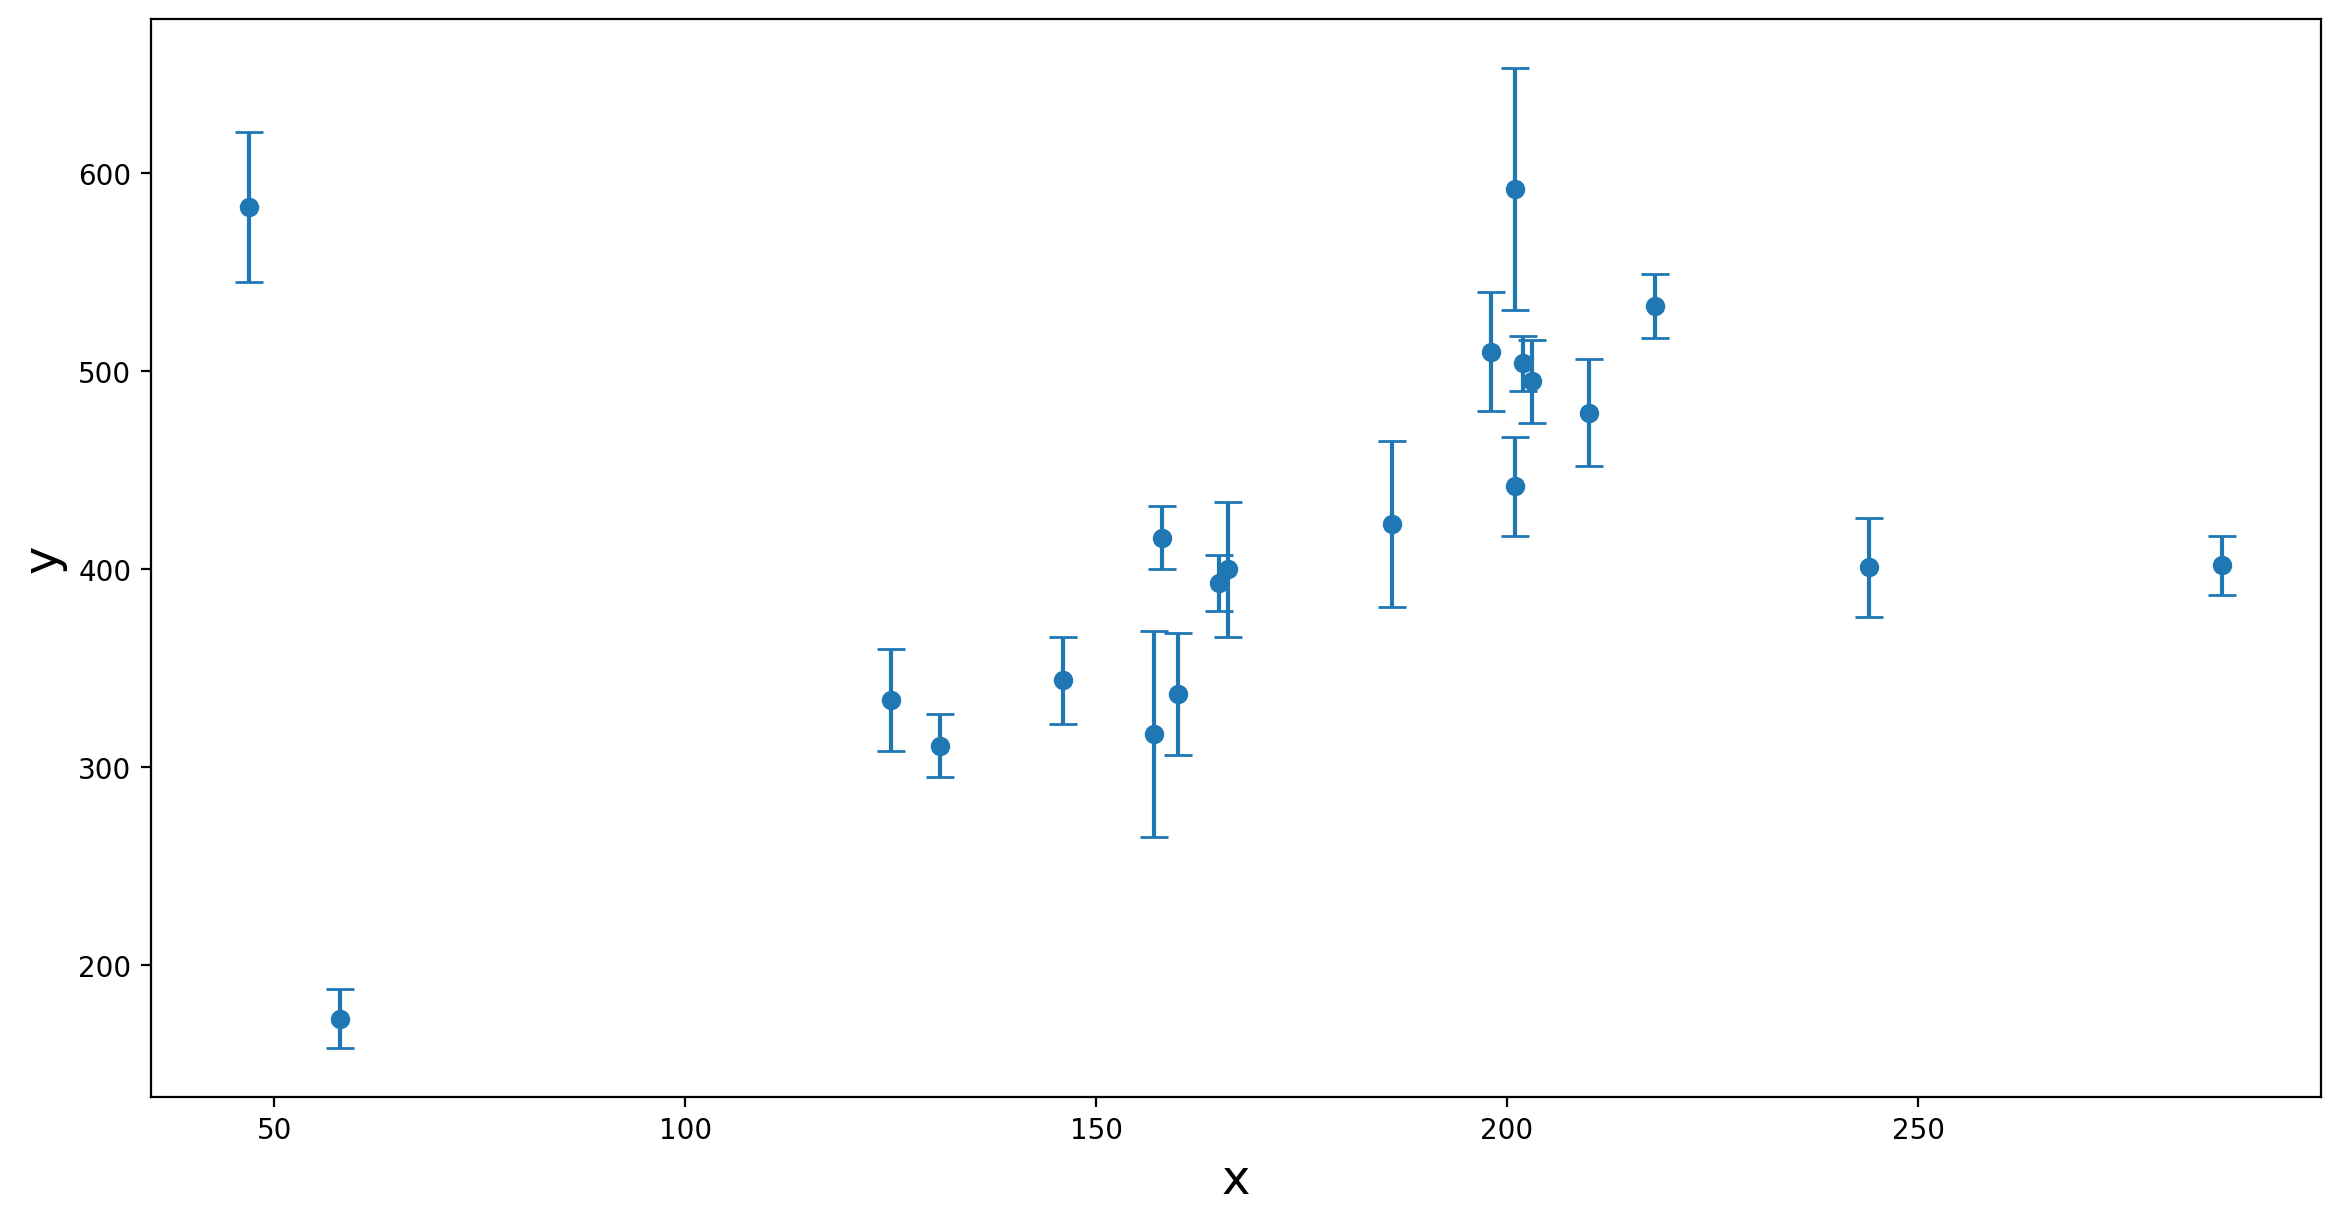

In [10]:
fig = plt.figure(figsize=(14, 7))
plt.errorbar(hogg_x[:, 0], hogg_y[:, 0], hogg_ys, None, marker="o", ls='', capsize=5)
plt.xlabel('x', fontsize='xx-large')
plt.ylabel('y', fontsize='xx-large');

## Ordinary least squares fit

Our first task is to calculate an ordinary least squares fit to ``hogg_data``.

Implement the `OLS` function, which:
- takes as an input a matrix of explanatory variables and a vector of responses
- and returns:
  - maximum likelihood estimation of a linear regression fit to this data (i.e. OLS solution),
  - residual sum of squares, i.e. $\sum_{i=1}^n (y_i - \mathbf{w}^\mathsf{T}\mathbf{x}_i)^2$.

In [11]:
def OLS(X, y):
    weights =  inv(X.T @ X) @ X.T @ y
    RSS = np.sum((X @ weights - y)**2)
    return weights, RSS

Now we can calculate and plot an OLS fit. <br>
Ordinary least squares disregards uncertainties in response variables, so we do not plot error bars.

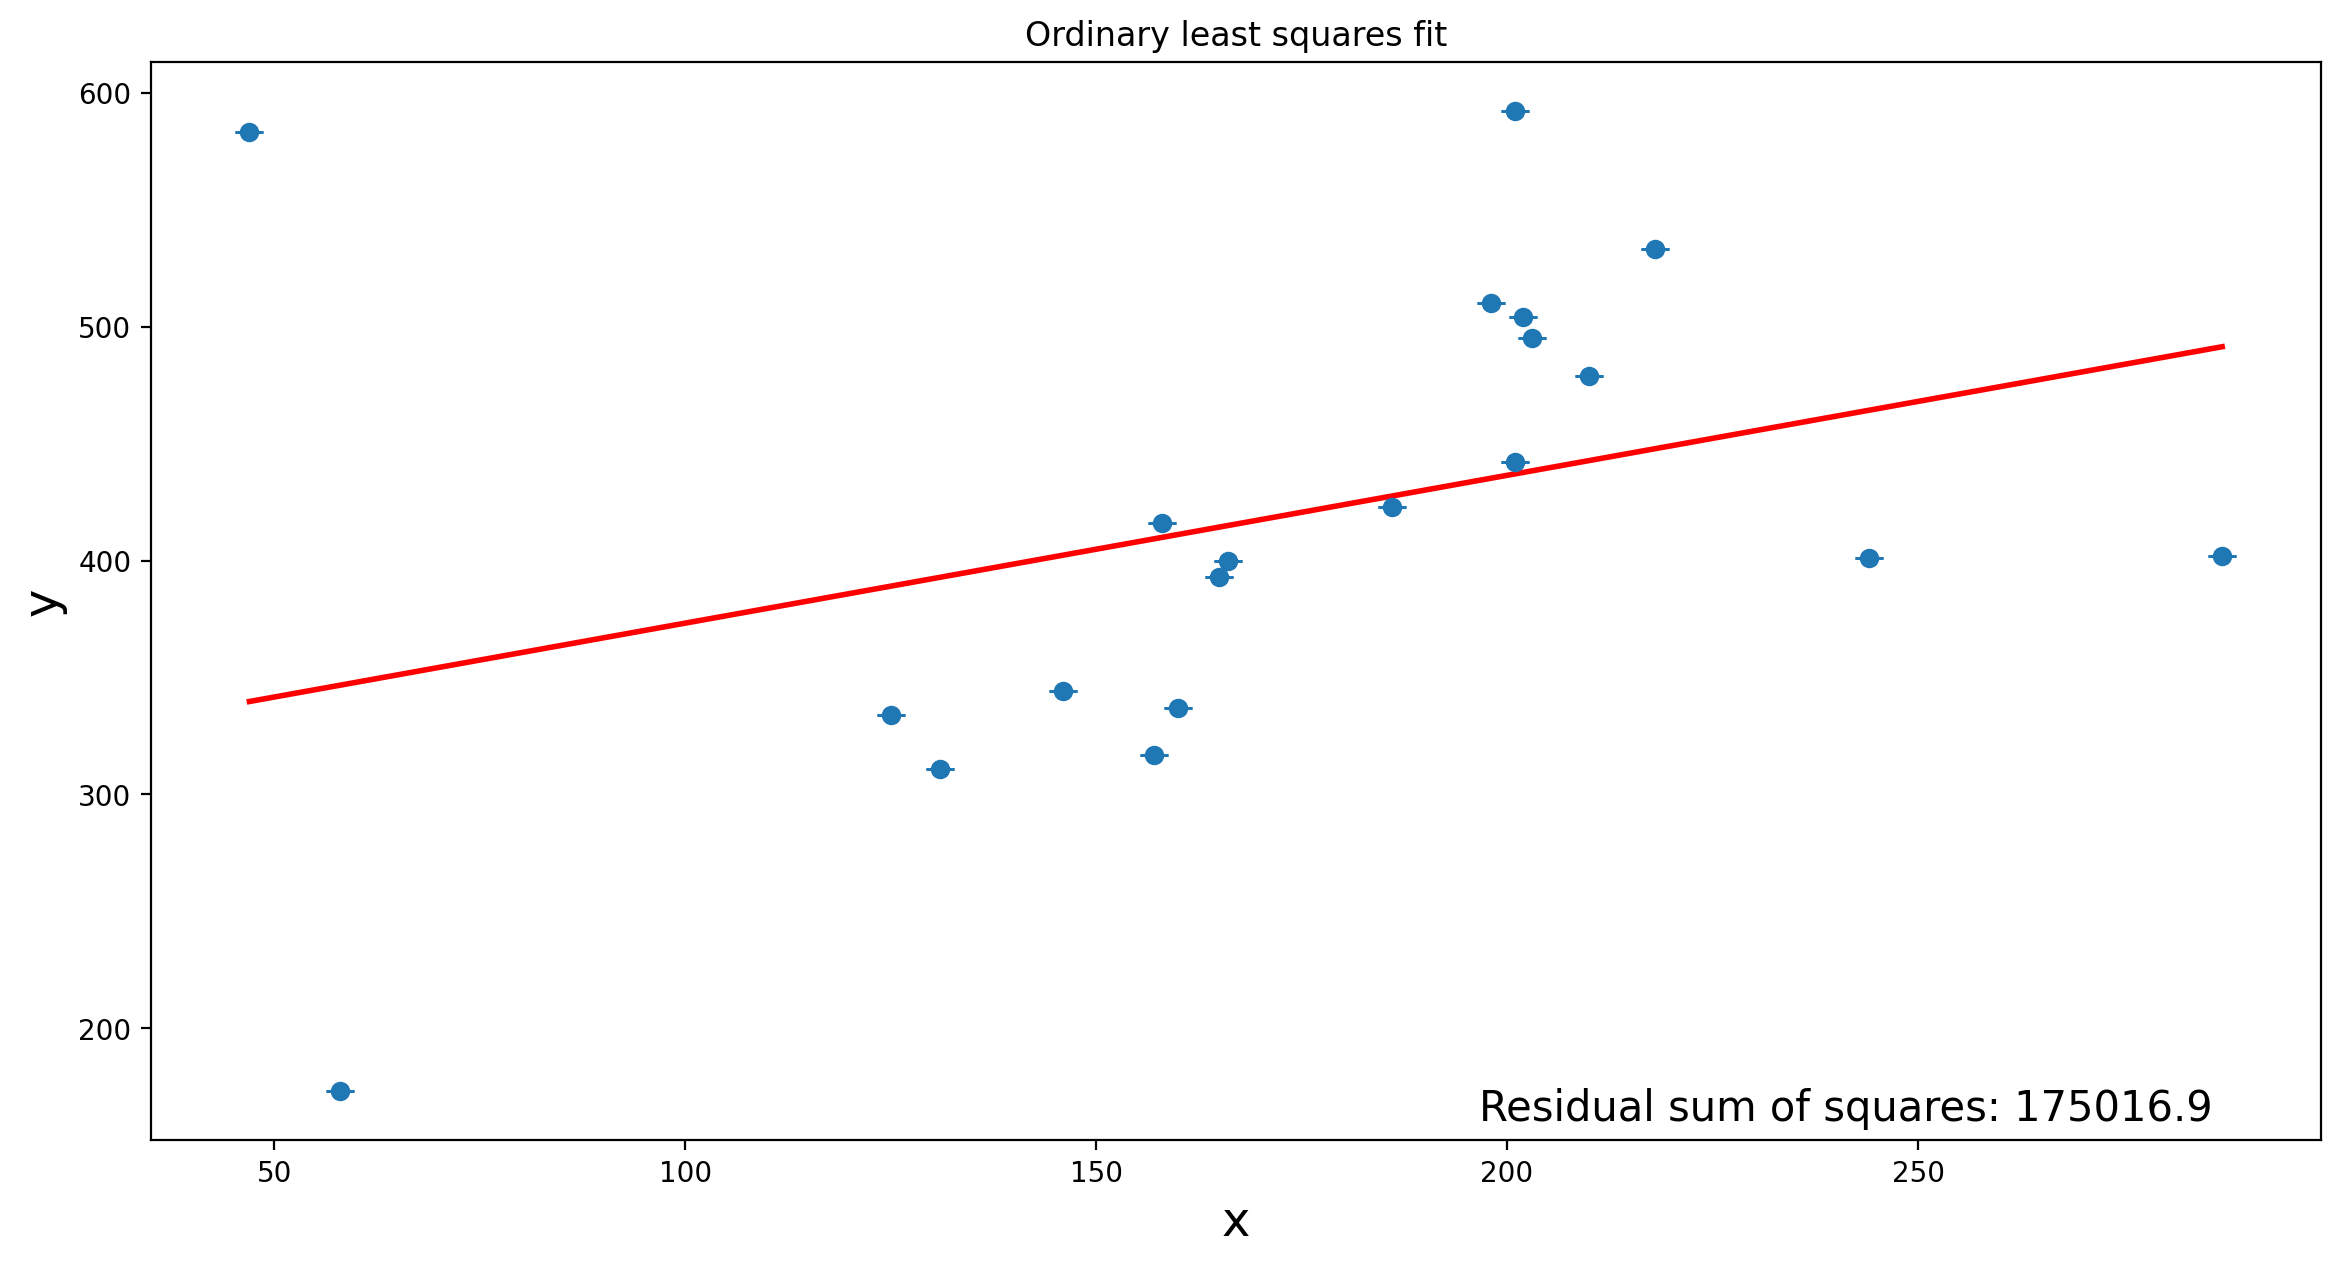

In [12]:
w, RSS = OLS(hogg_x, hogg_y)

fig = plt.figure(figsize=(14, 7))
plot_fit(plt.gca(), w, hogg_x, hogg_y, 0, RSS=RSS, title='Ordinary least squares fit')

Is this a convincing fit?

## Bayesian linear regression

To gain insight into uncertainty of our fit, we must move to Bayesian modeling.

Implement `bayes_lin_reg` function, which:
- takes as an input:
    - prior mean and covariance of the regression parameters $\mathbf{w}$,
    - response uncertainty ($\sigma$ hyperparameter),
    - matrix of explanatory variables and vector of responses,
- and returns parameters of the posterior distribution over $\mathbf{w}$ (mean and covariance).

In [13]:
def bayes_lin_reg(prior_mu, prior_Sigma, sigma, X, y):
    posterior_Sigma =  inv(inv(prior_Sigma) + (1/sigma**2) * X.T @ X)
    posterior_mu = posterior_Sigma @ ((1/sigma**2) * X.T @ y + inv(prior_Sigma) @ prior_mu)
    return posterior_mu,posterior_Sigma

Now we need to propose a reasonable prior for $\mathbf{w}$.

Propose and justify (in a comment) mean and covariance for the prior distribution over $\mathbf{w}$. You can use an informative prior.

In [91]:
mu_0 = np.array([[2],[80]])
Sigma_0 = np.array([
    [4,0],
    [0,160**2]
])

#  ----  prior dla mu -----
# patrząc na największe zagęszczenie danych z przedziału 125-225, wartości przyjmowane były z zakresu 300-500, zatem przyjęto średnią wartość 2,
# natomiast dla wartości b, prosta dla największego zbioru danych dla której przyjęto średnią wartość parametru a może przecinać oś OY dla wartości y z przedziały [0,160] dlatego wybrano wartość 80.


# ----  prior dla sigma -----
# dla mu przyjęto wartość 2^2, trend rosnący jest zauważalny, nie jestem tylko pewny jego poziomu,
# jeżeli chodzi o paramter b, zastosowano wartość160**2 wynikającą z dużego zakresu przedziału o czym wspominam wyżej


# Nie zauważam w danych żadnych szczegółów, które miałyby wpłynąć na kowariancję między zmiennymi

In [92]:
mu_1,Sigma_1 = bayes_lin_reg(mu_0, Sigma_0, 25, hogg_x[:1], hogg_y[:1])
print(mu_1,"\n\n")
print(Sigma_1)

[[ 2.47085381]
 [94.99236007]] 


[[ 5.58486709e-01 -1.09580523e+02]
 [-1.09580523e+02  2.21108689e+04]]


### Posterior distributions

We are now ready to calculate posterior distributions over parameters of our linear regression fits.

To gain an insight into behavior of these posteriors, we will plot:
- Prior.
- Posterior after observing just one data point. <br>
  <u>Look at the distribution of the regression slope (when we know just one data point). Write your conclusions about this distribution in a comment below the plots</u>.
- Posterior after observing 5 data points.
- Posterior after observing all data points.

<u>Why these posteriors are oriented "diagonally". Answer in a comment below the plots</u>.

In [93]:
def plot_posteriors():
    mu_1, Sigma_1 = bayes_lin_reg(mu_0, Sigma_0, sigma, hogg_x[:1], hogg_y[:1])
    mu_10, Sigma_10 = bayes_lin_reg(mu_1, Sigma_1, sigma, hogg_x[1:10], hogg_y[1:10])
    mu_n, Sigma_n = bayes_lin_reg(mu_10, Sigma_10, sigma, hogg_x[10:], hogg_y[10:])
    
    _, ax = plt.subplots(2, 2, figsize=(8,8))
    plot_mvn(ax[0, 0], mu_0, Sigma_0, title='Prior')
    plot_mvn(ax[0, 1], mu_1, Sigma_1, title='Posterior after 1 observation')
    plot_mvn(ax[1, 0], mu_10, Sigma_10, title='Posterior after 10 observations')
    plot_mvn(ax[1, 1], mu_n, Sigma_n, title='Posterior after all observations')

We start with posteriors when response uncertainty $\sigma = 25.0$

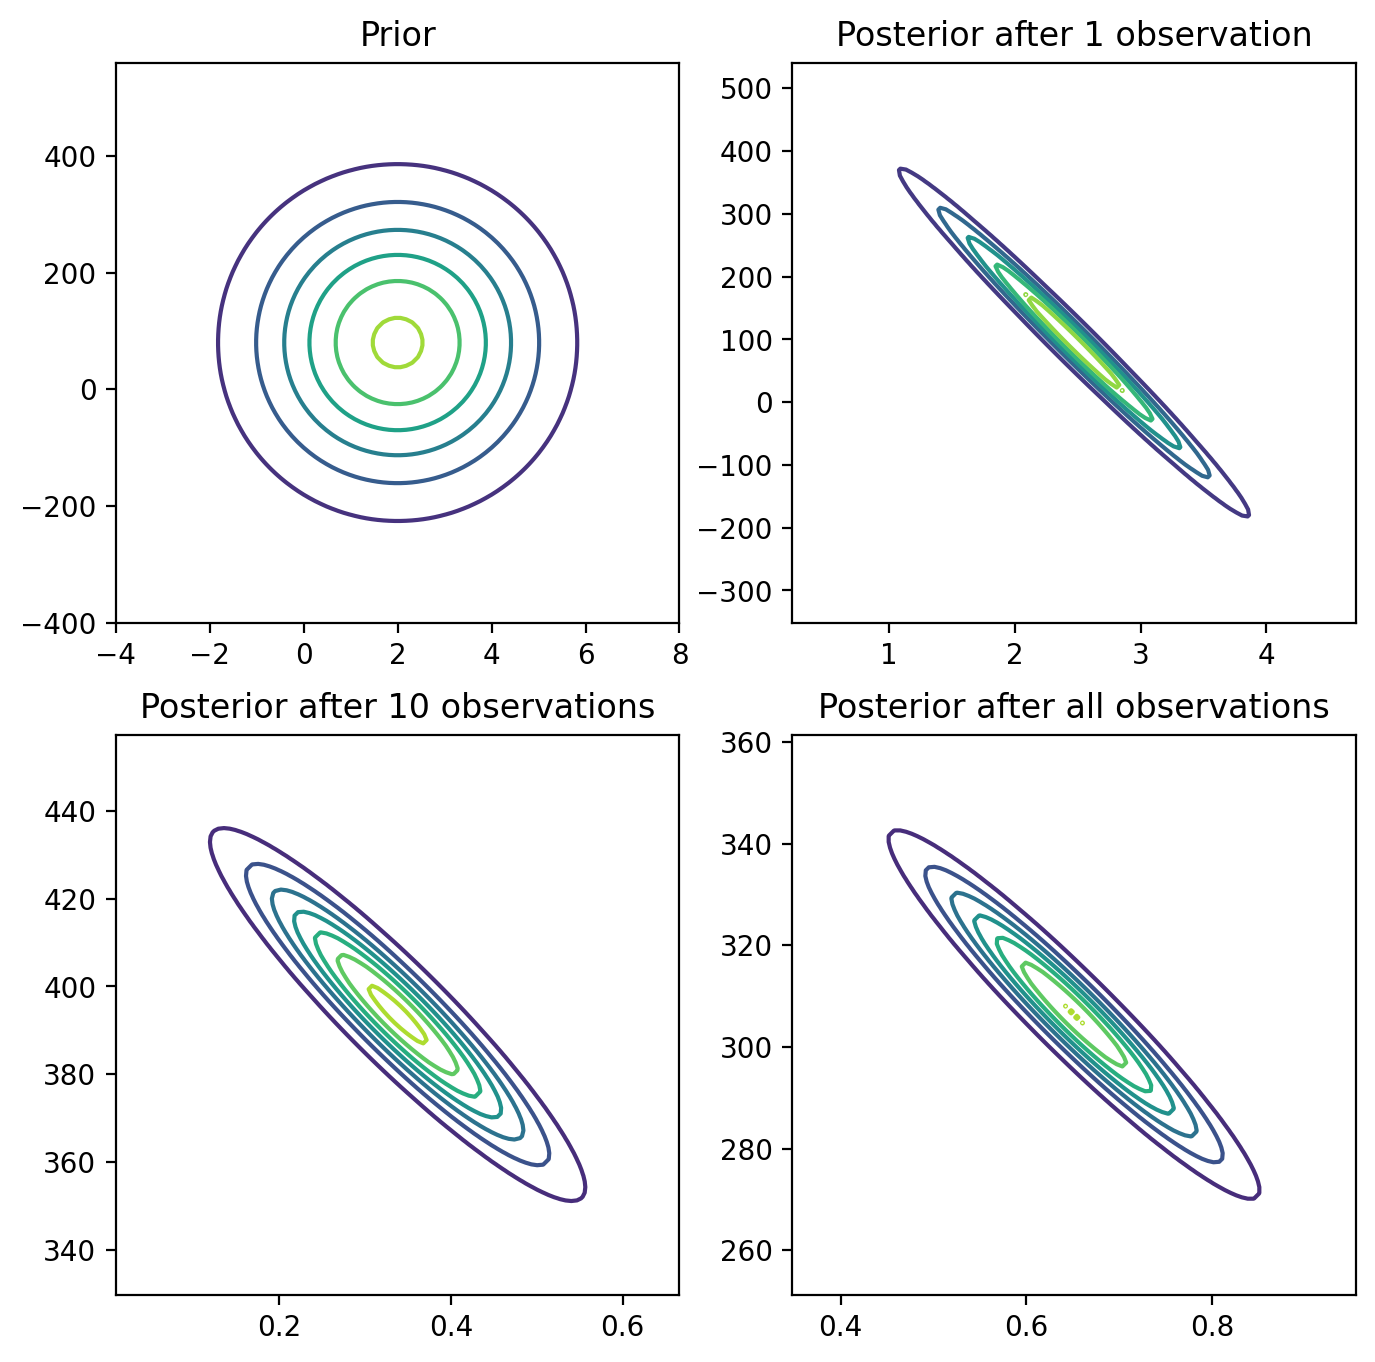

In [94]:
sigma = 25.

plot_posteriors()

Let's see what happens when response uncertainty increases to $\sigma = 100.0$

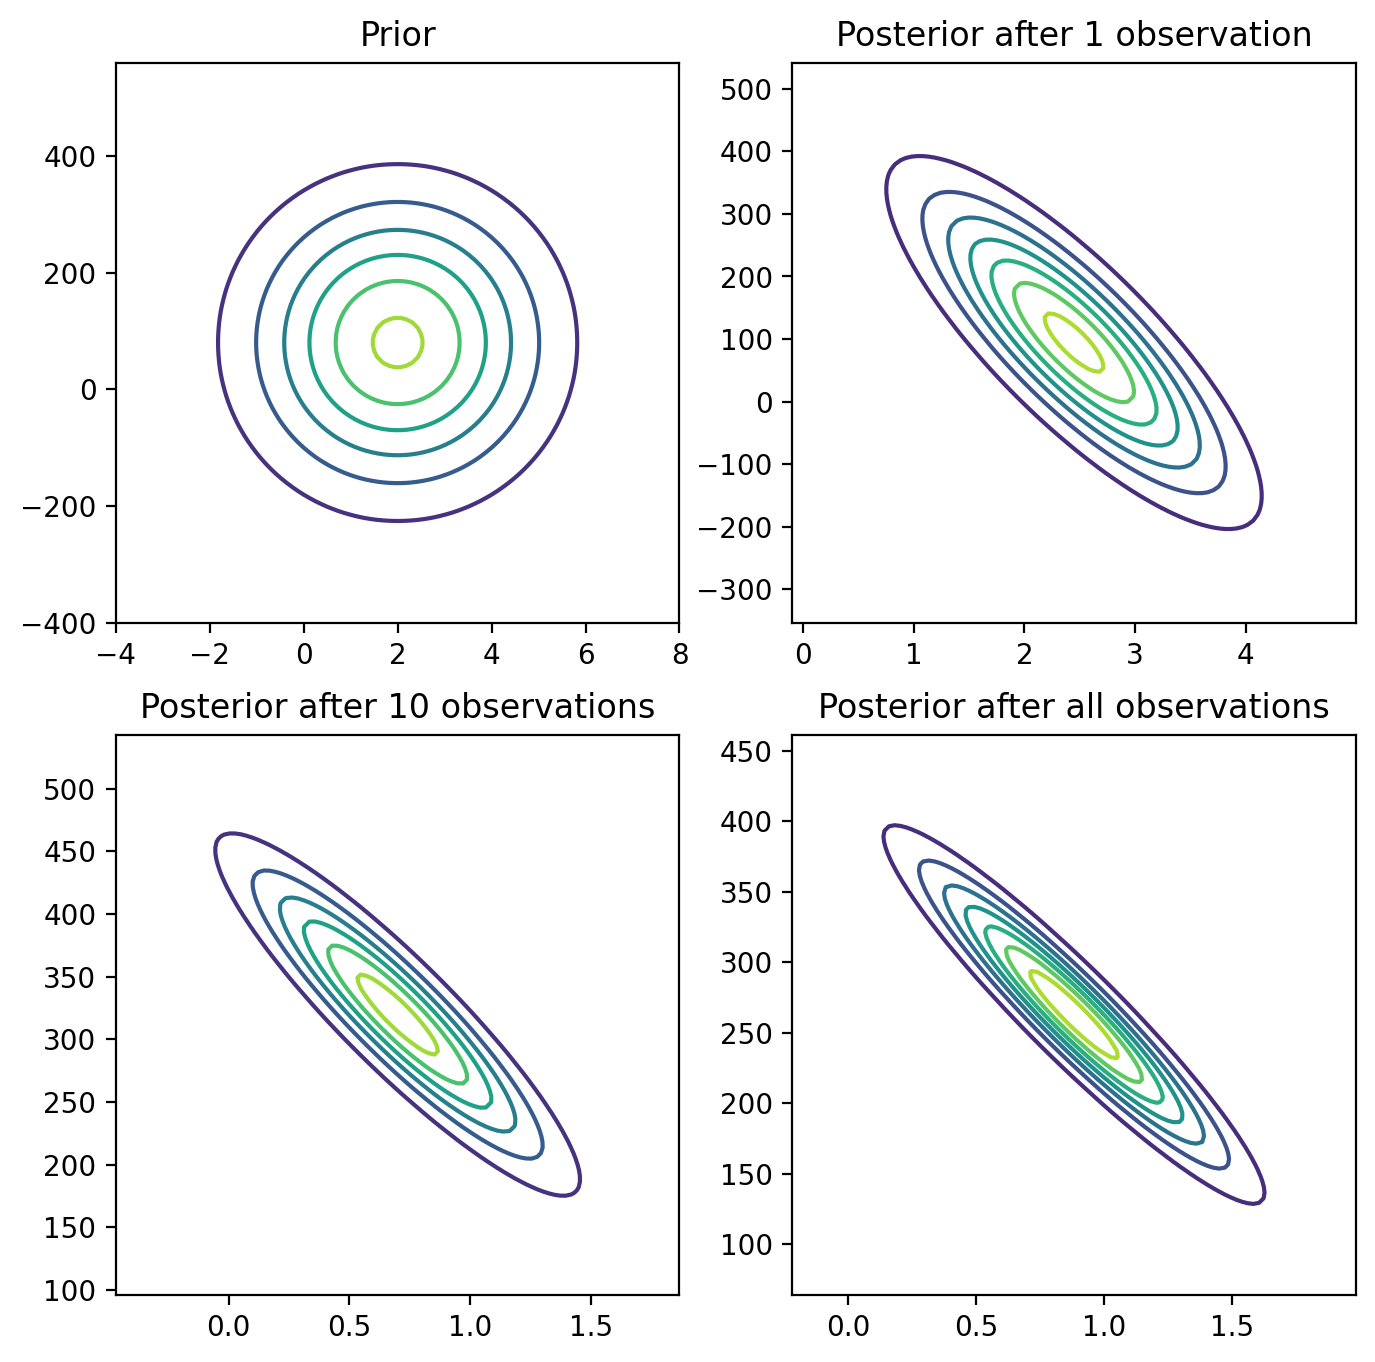

In [95]:
sigma = 100.

plot_posteriors()

In [ ]:
# wykresy są przechylone ponieważ chcą dopasować się do zaobserwowanych danych, dla małego a, wartość b jest na poziomie 400 gdzie znajduje się duż grupa danych,
# analogicznie dla dużego a, b musi być bardzo małe aby po gwałtownym wzroście prosta przechodziła przez duże skupisko punktów

### MAP fit

Let's try another point estimate for $\mathbf{w}$ - maximum a posteriori estimate.

First, we calculate a posterior distribution:

In [96]:
sigma = 25.

mu_n, Sigma_n = bayes_lin_reg(mu_0, Sigma_0, sigma, hogg_x, hogg_y)

print(mu_n,"\n\n", Sigma_n)

[[  0.65141031]
 [306.38195974]] 

 [[ 1.02321698e-02 -1.76954011e+00]
 [-1.76954011e+00  3.37234208e+02]]


Now, find the MAP estimate for $\mathbf{w}$ and store it in `w_map`.

In [97]:
w_map = mu_n
# jest to rozkład normalny więdz MAP = mu

Let's plot this MAP fit. We will use $\sigma$ as response uncertainty (error bars).

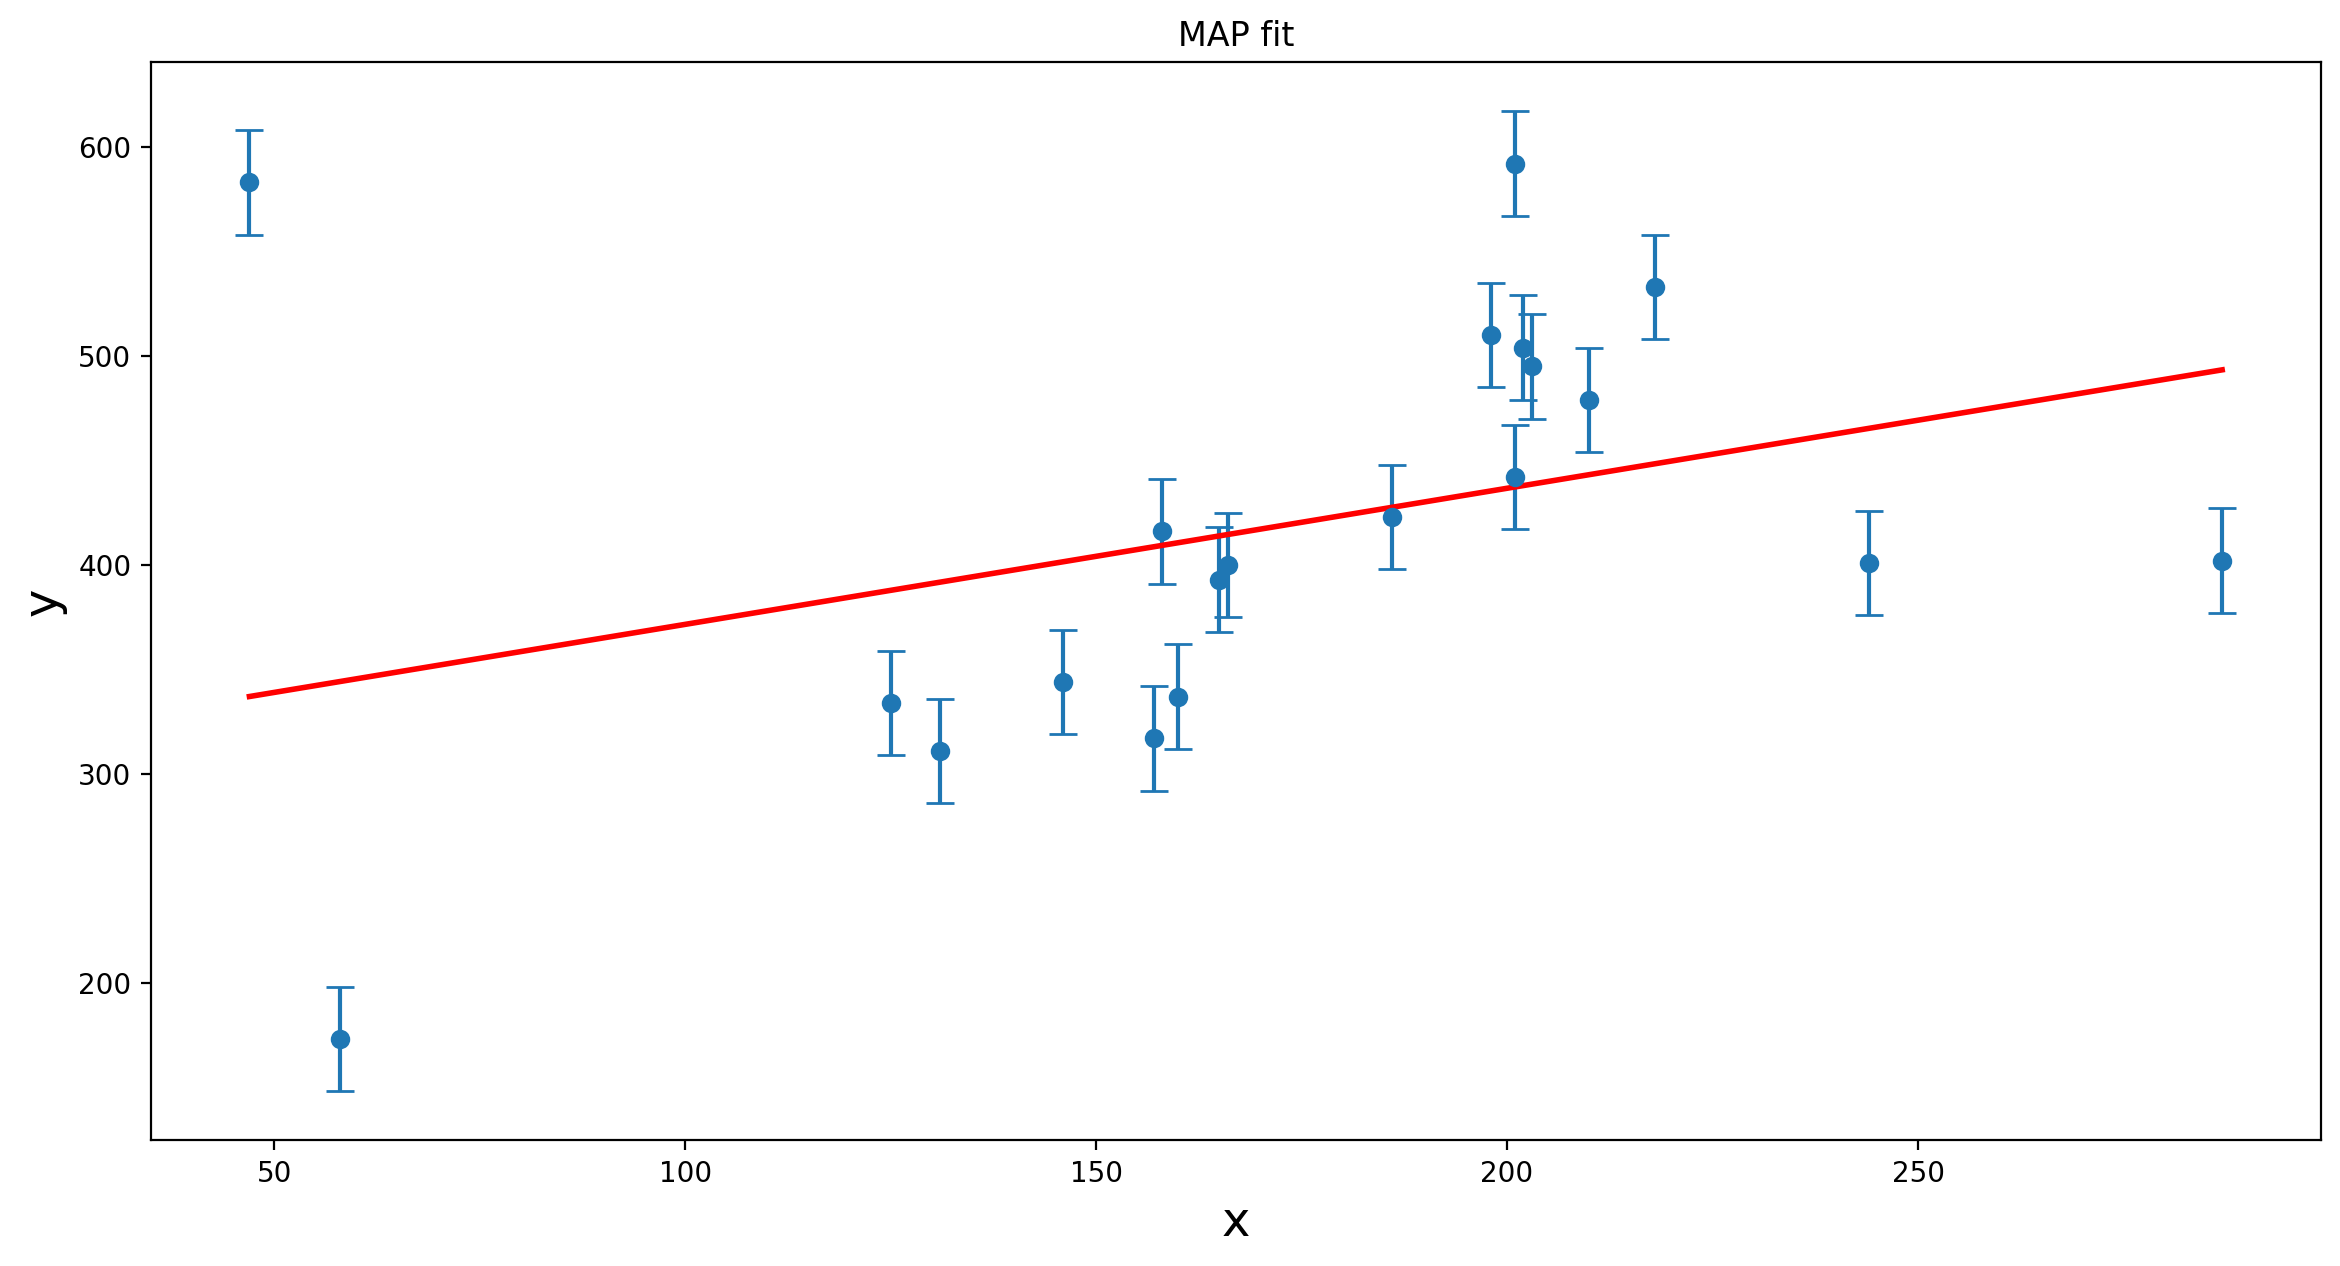

In [98]:
fig = plt.figure(figsize=(14, 7))
ax = plt.gca()

plot_fit(ax, w_map, hogg_x, hogg_y, sigma, title='MAP fit')

Is this fit convincing? How does it compare to OLS?

### Uncertainty in our fit

There is a simple way to judge the uncertainty in our regression fits - we can draw many samples from the posterior over $\mathbf{w}$ and then plot them together.

Let's start by calculating the posterior again. For now we assume that response uncertainty is $\sigma = 25.0$.

In [99]:
sigma = 25.

mu_n, Sigma_n = bayes_lin_reg(mu_0, Sigma_0, sigma, hogg_x, hogg_y)
mu_n = np.squeeze(mu_n)

Now, generate 50 samples from the posterior. Store them in `w_samples_1`.

In [100]:
N_samples = 50
w_samples_1 = mvn.rvs(mu_n,Sigma_n,N_samples)

Let's plot these samples.

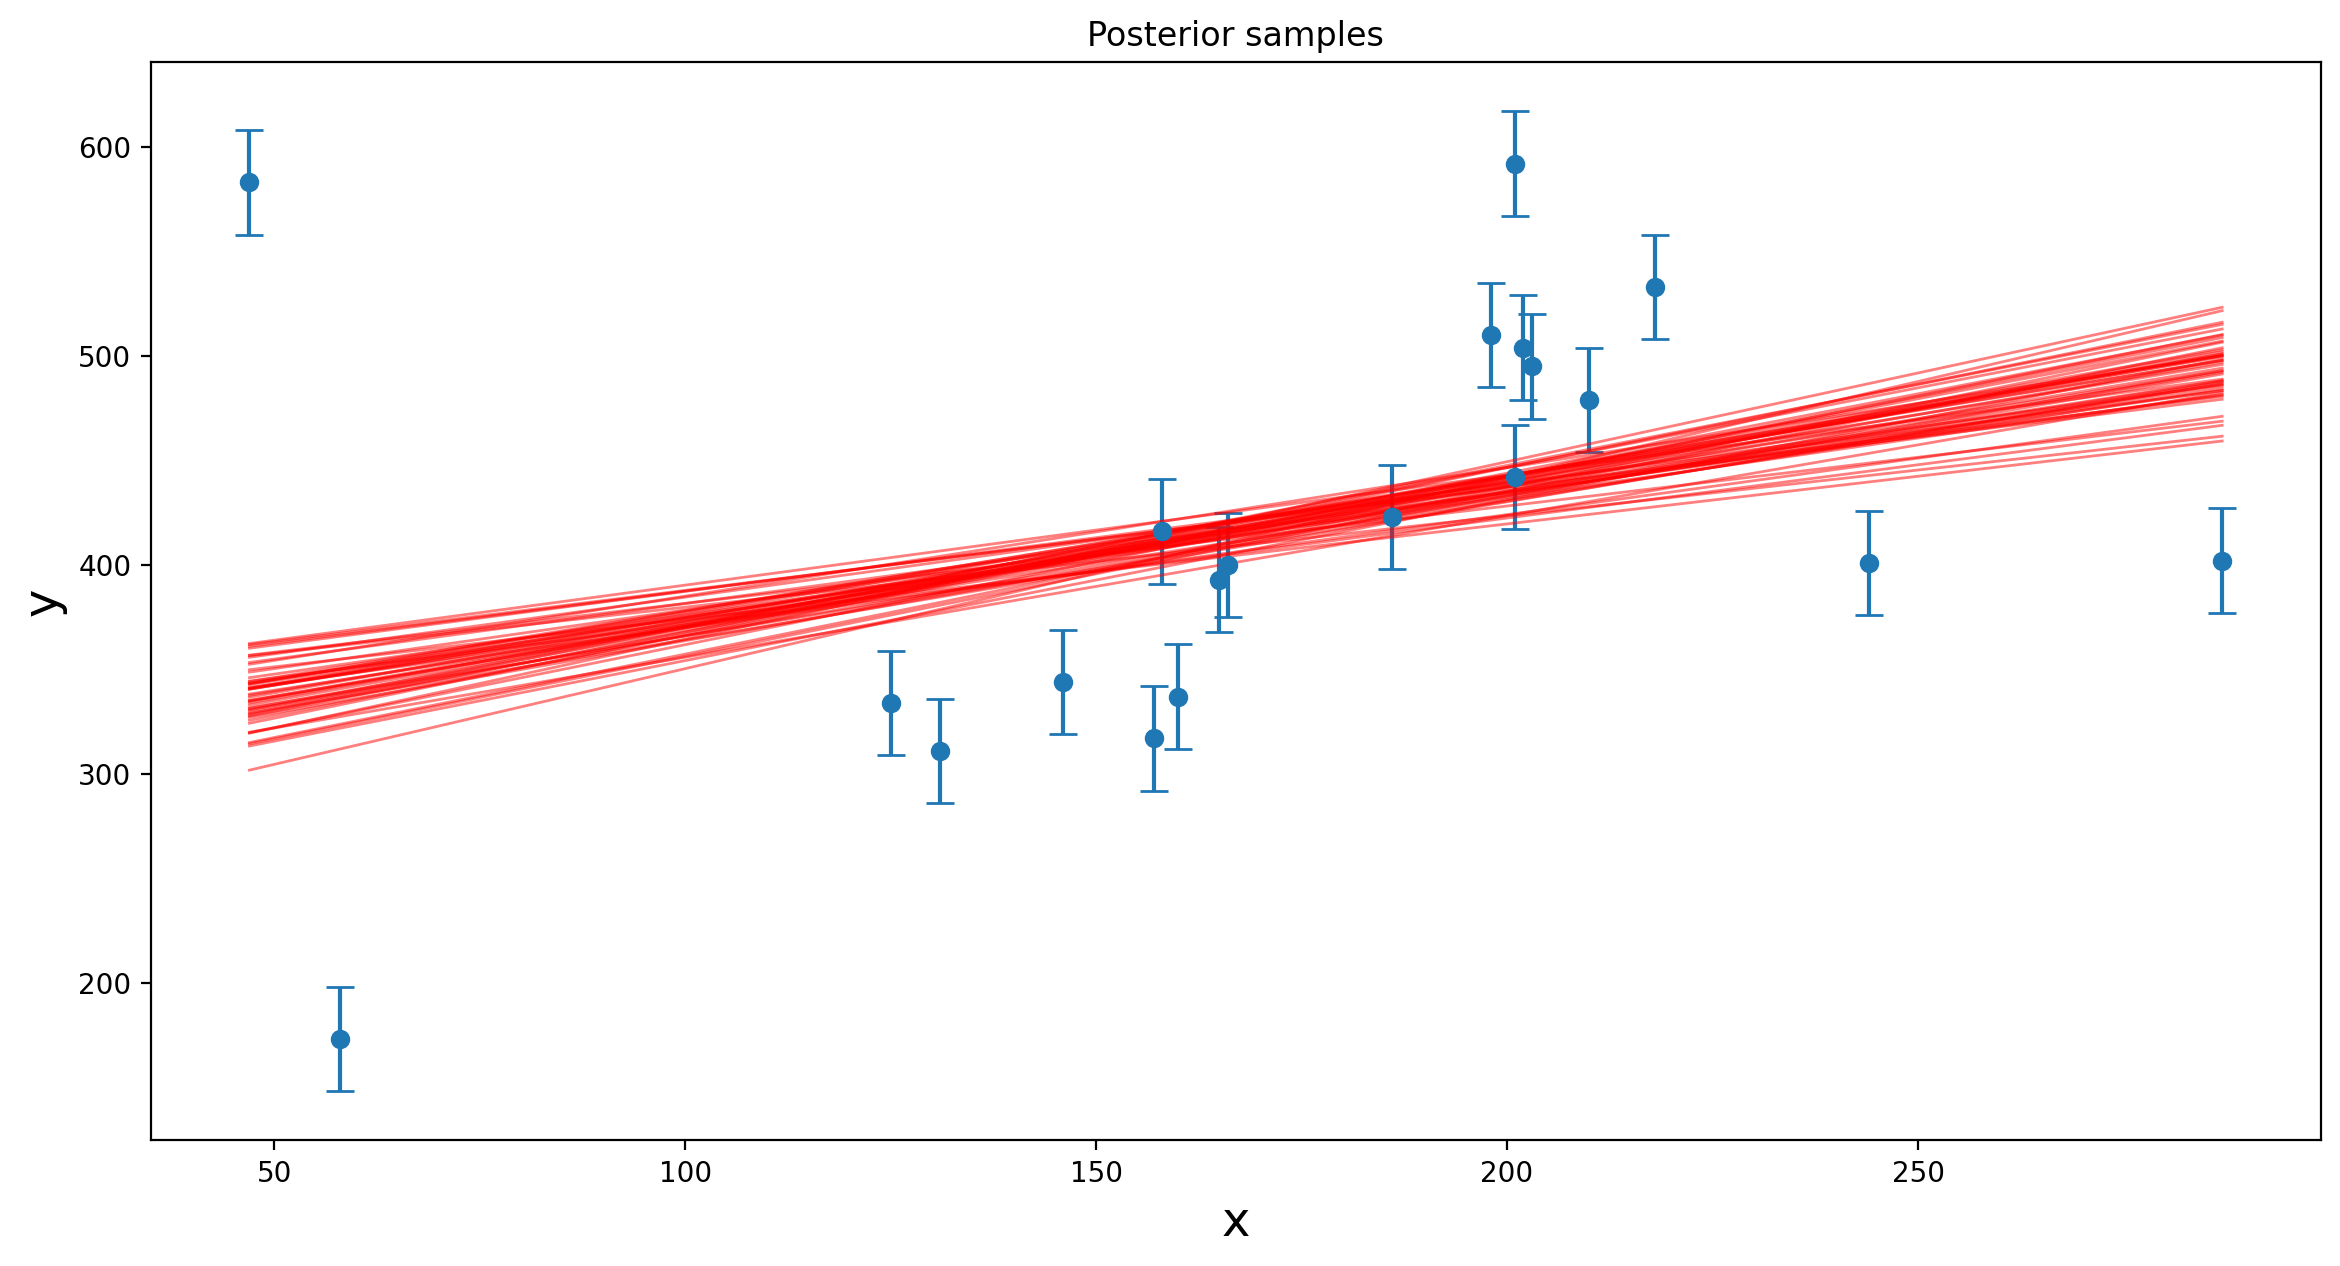

In [101]:
fig = plt.figure(figsize=(14, 7))
plot_posterior_samples(plt.gca(), w_samples_1, hogg_x, hogg_y, sigma, title='Posterior samples')

What would happen if response uncertainty was $\sigma = 100.0$? Would this increase uncertainty in our fits?

In [102]:
sigma = 100.

mu_n, Sigma_n = bayes_lin_reg(mu_0, Sigma_0, sigma, hogg_x, hogg_y)
mu_n = np.squeeze(mu_n)

Generate 50 samples from this new posterior and store them in `w_samples_2`.

In [103]:
w_samples_2 = mvn.rvs(mu_n,Sigma_n,N_samples)

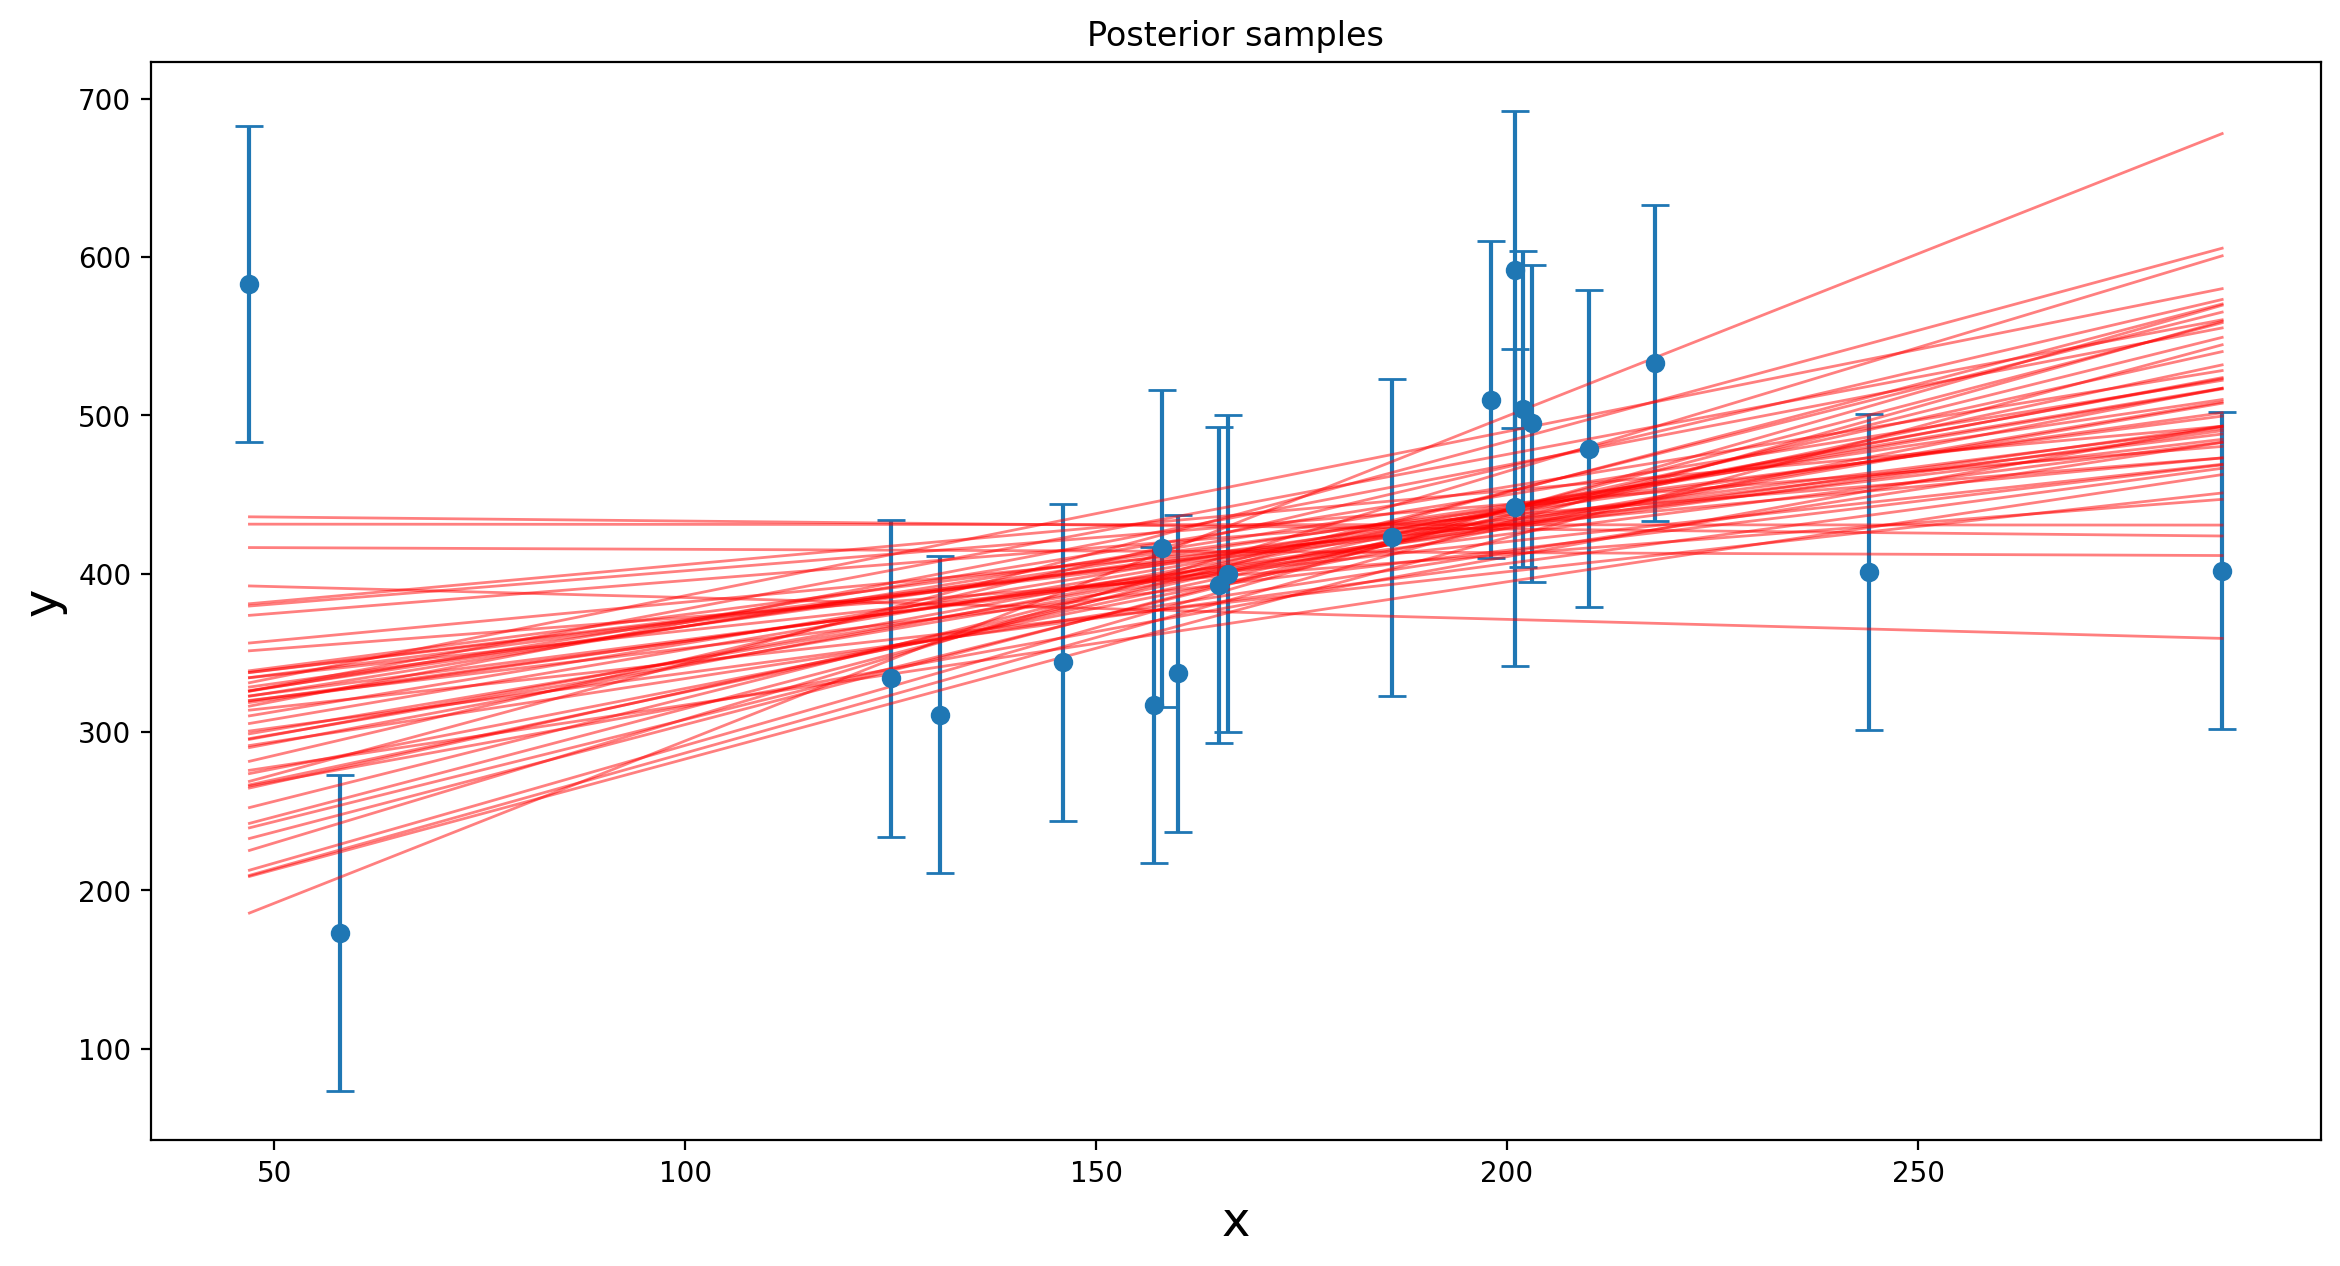

In [104]:
fig = plt.figure(figsize=(14, 7))
plot_posterior_samples(plt.gca(), w_samples_2, hogg_x, hogg_y, sigma, title='Posterior samples')

Did the fit uncertainty increase?

### Posterior predictive

Finally, let's do some predictions for new (previously unobserved) data points.

In [105]:
test_x = np.array([[-150, 1],
                   [130, 1],
                   [280, 1]])

Implement `posterior_predictive` function, which:
- takes as an input:
    - posterior mean and covariance of the regression parameters $\mathbf{w}$
      (i.e. $\boldsymbol \mu_n$ and $\boldsymbol \Sigma_n$),
    - response uncertainty ($\sigma$ hyperparameter),
    - a vector of explanatory variables $\mathbf{x}$,
- and returns mean and standard deviation of the posterior predictive distribution
  $p(y \mid \mathbf{x}, \boldsymbol \mu_n, \boldsymbol \Sigma_n, \sigma)$<br>

This posterior predictive distribution describes our believs about the response $y$ predicted for the input $\mathbf{x}$.

In [106]:
def posterior_predictive(posterior_mu, posterior_Sigma, sigma, x):
    posterior_predictive_mu = posterior_mu.T @ x
    posterior_predictive_Sigma = sigma**2 + x.T @ posterior_Sigma @ x

    return posterior_predictive_mu[0],posterior_predictive_Sigma

Now, let's calculate posterior over $\mathbf{w}$ (assuming $\sigma = 25.0$)

In [107]:
sigma = 25.
mu_n, Sigma_n = bayes_lin_reg(mu_0, Sigma_0, sigma, hogg_x, hogg_y)

In [108]:
 y_mu, y_sigma = posterior_predictive(mu_n, Sigma_n, sigma, test_x[0])
 print(y_mu,y_sigma)

208.6704133074286 1723.3200624348453


and use it to make predictions:

In [109]:
y_mu, y_sigma = np.empty(3), np.empty(3)
for idx, x in enumerate(test_x):
    y_mu[idx], y_sigma[idx] = posterior_predictive(mu_n, Sigma_n, sigma, x)

We can now plot our predictions. We plot:
  - expected value of $y$,
  - uncertainty about the predicted $y$, i.e. one standard deviation of $y$ (error bars),
  - mean posterior fit to the (training) data.

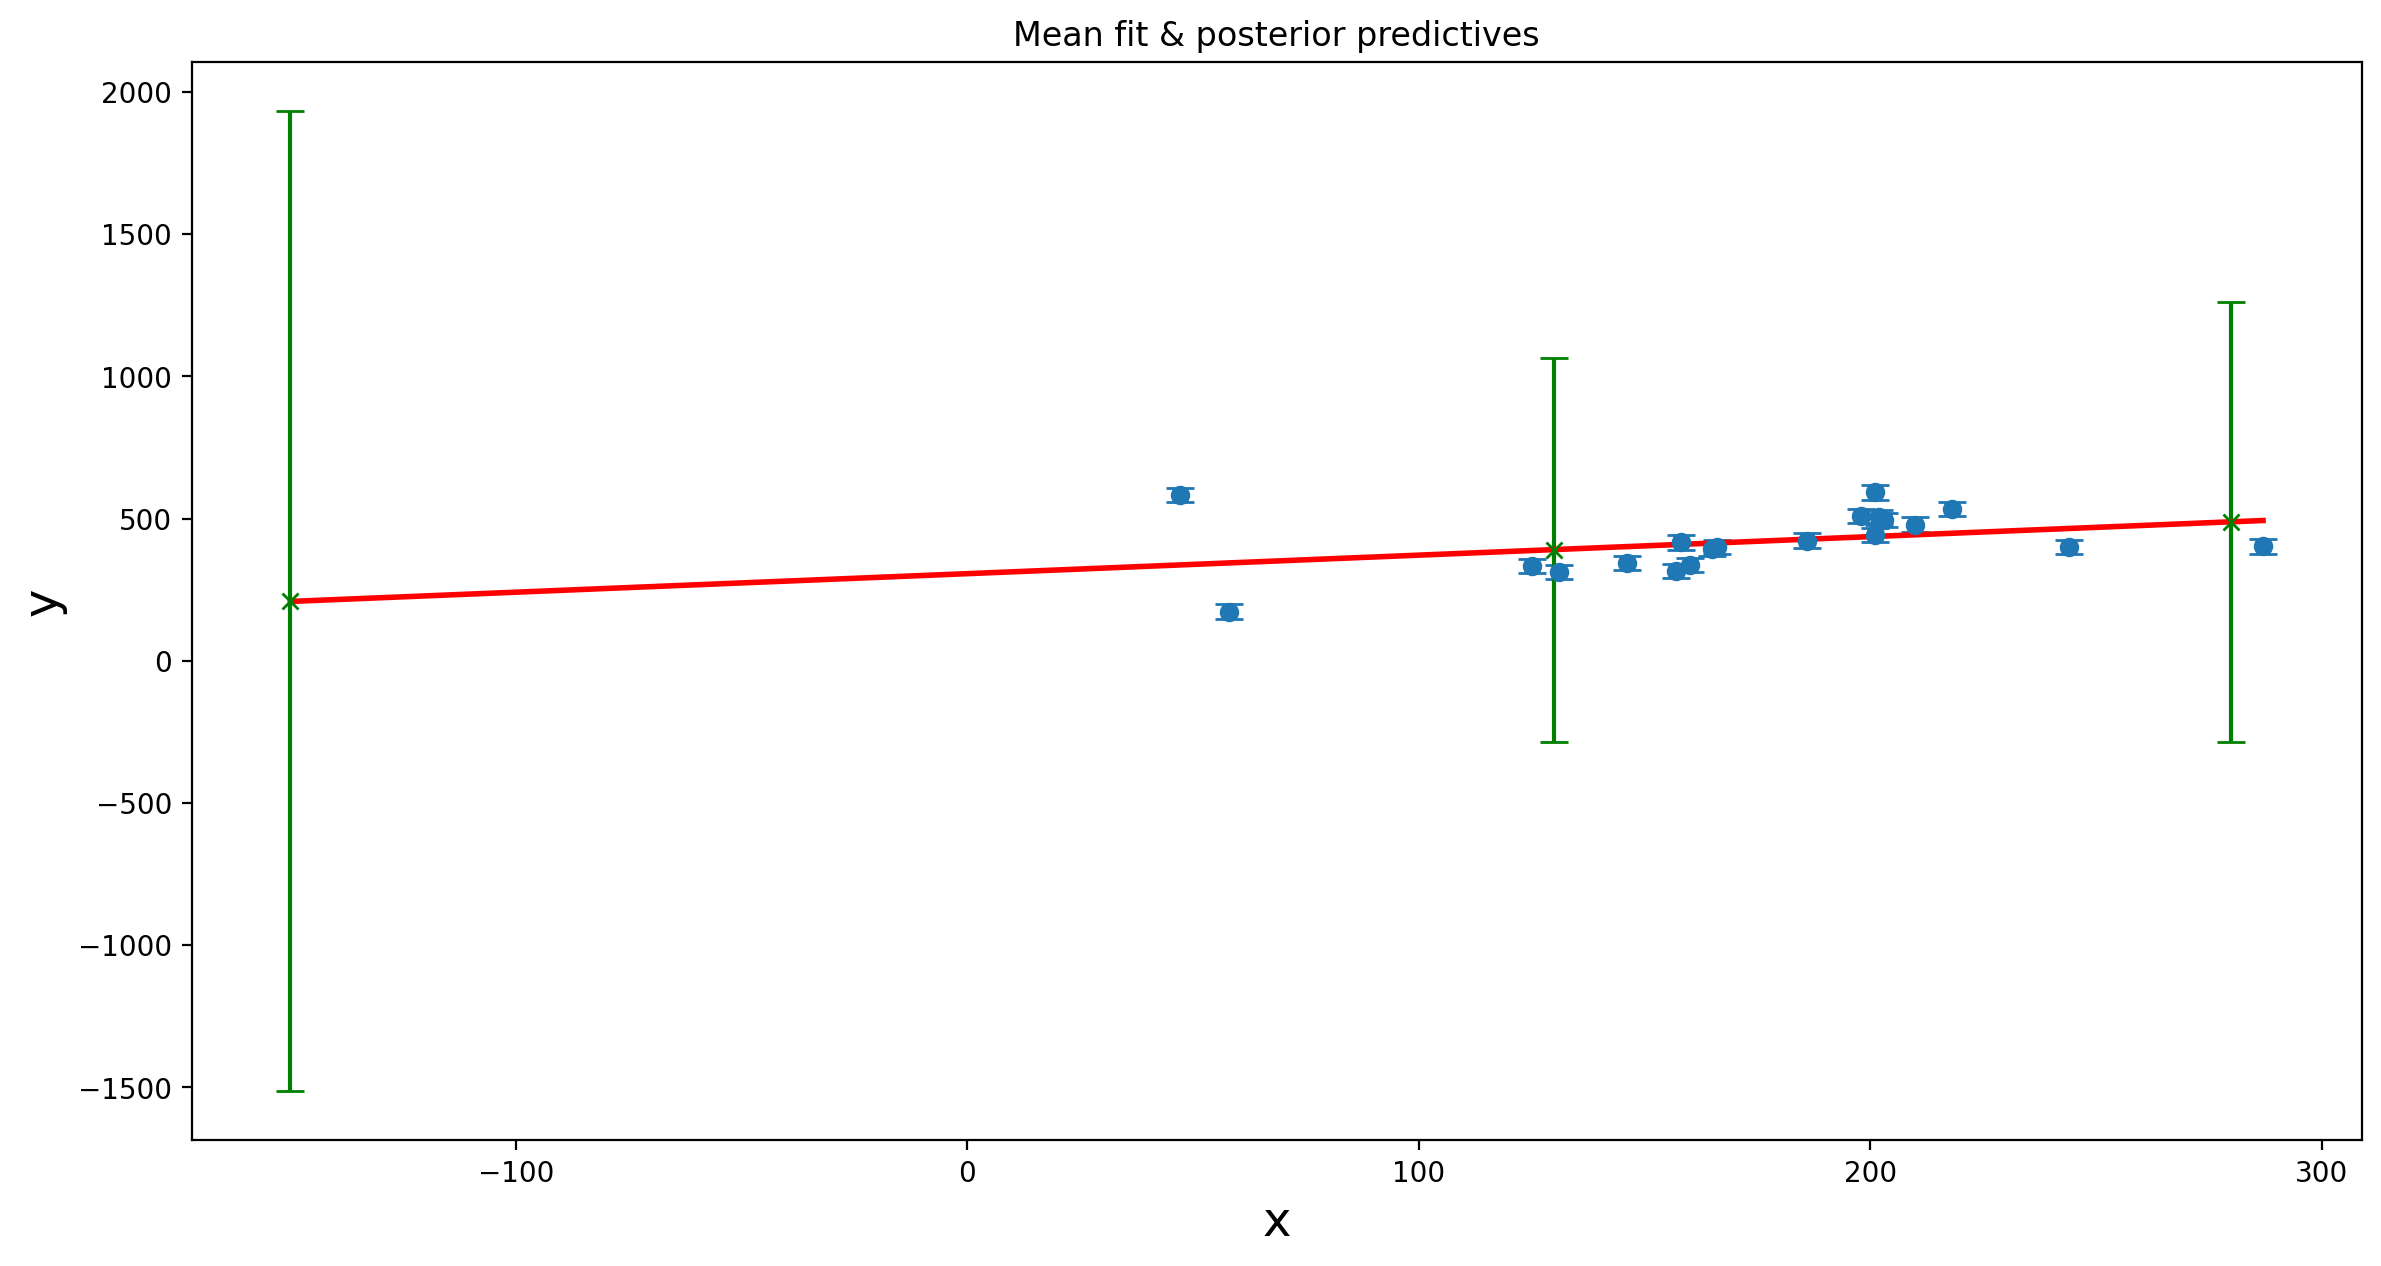

In [110]:
fig = plt.figure(figsize=(14, 7))
ax = plt.gca()
plot_fit(ax, mu_n, hogg_x, hogg_y, sigma,
         test_x=test_x, test_y=y_mu, test_ys=y_sigma,
         title='Mean fit & posterior predictives')

In [111]:
print(y_sigma)

[1723.32006243  675.07744751  773.49385472]


Note that:
  - expected value of the predicted $y$ lies exactly on the posterior mean fit.
  - when we make predictions away from the data points our uncertainty about predicted value increases.